# Chargement du dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("chandramoulinaidu/spam-classification-for-basic-nlp")

print("Path to dataset files:", path)

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data = pd.read_csv('/kaggle/input/spam-classification-for-basic-nlp/Spam Email raw text for NLP.csv')
data

# Prétraitement des données

- la Suppression des balises HTML

In [ ]:
from bs4 import BeautifulSoup
def remove_html_tags_bs4(text):
    return BeautifulSoup(text, "html.parser").get_text()
data['MESSAGE'] = data['MESSAGE'].apply(remove_html_tags_bs4)
display(data.head())

- La Suppression des caractères spéciaux

In [ ]:
import re

def remove_special_characters(text):
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['MESSAGE'] = data['MESSAGE'].apply(remove_special_characters)
display(data.head())

- La tokenisation du texte

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

data['MESSAGE'] = data['MESSAGE'].apply(word_tokenize)
display(data.head())

- La conversion du texte en minuscules

In [ ]:
data['MESSAGE'] = data['MESSAGE'].apply(lambda x: [word.lower() for word in x])
display(data.head())

- La suppression de la ponctuation

In [ ]:
import string

def remove_punctuation(tokens):
    return [word for word in tokens if word not in string.punctuation]

data['MESSAGE'] = data['MESSAGE'].apply(remove_punctuation)
display(data.head())

- La suppression des mots vides (stopwords)

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
data['MESSAGE'] = data['MESSAGE'].apply(lambda x: [word for word in x if word not in stop_words])
display(data.head())

- Lemmatisation des mots

In [ ]:
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

data['MESSAGE'] = data['MESSAGE'].apply(lemmatize_words)
display(data.head())

In [ ]:
len(data['MESSAGE'])

# Word embeddings

- Bag of Words

Bag of Words BoW (sac de mots) est l’une des méthodes les plus simples pour représenter un texte sous forme numérique.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
data["MESSAGE"] = data["MESSAGE"].astype(str)

bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(data["MESSAGE"])
print("--- Feature Names - vocabulaire ---")
print(bow_vectorizer.get_feature_names_out())
print("\n--- forme de la matrice ---")
print("BoW shape :", X_bow.shape)


In [ ]:
vocab = bow_vectorizer.get_feature_names_out()
print("Taille du vocabulaire :", len(vocab))
print(vocab[:50])  # les 50 premiers mots


In [ ]:
print("\n--- les 200 mots et leurs counts ---")
print(X_bow.toarray()[0][:200])

- TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(data["MESSAGE"])

print("--- Feature Names vocabulaire ---")
print(tfidf_vectorizer.get_feature_names_out())
print("\n--- forme de la matrice TF-IDF ---")
print(X_tfidf.shape)


In [ ]:
print("\n--- 50 premiers mots et leurs scores tf-IDF ---")
print(X_tfidf.toarray()[0][:50])

- SVM

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# Diviser les données
X_train, X_test, y_train, y_test = train_test_split( X_tfidf, data['CATEGORY'],  test_size=0.2, random_state=42)

# Initialiser SVM
svm_model = LinearSVC()

# Entraîner
svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

- Evaluation du model SVM

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# faire les prédictions
y_pred = svm_model.predict(X_test)

# calculer les metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# générer la matrice de  confusion
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- Word2Vec Embeddings (Gensim)

In [ ]:
import sys
!{sys.executable} -m pip install pyldavis gensim

In [ ]:
#transformer la colonne MESSAGE en texte, ['dear', 'homeowner', 'interest', 'rate', 'low} --> 'dear homeowner interest rate low'

In [ ]:
display(data['MESSAGE'])

In [ ]:
# Word2Vec
from gensim.models import Word2Vec
import numpy as np
import ast

# Convert the string representation of lists back to actual lists of tokens
sentences = data["MESSAGE"].apply(ast.literal_eval).tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # taille du vecteur
    window=5,
    min_count=2,
    workers=4
)

# Créer un vecteur par mail en faisant la moyenne des vecteurs de ses mots
w2v_vectors = []

for tokens in sentences:
    vects = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    if len(vects) == 0:
        w2v_vectors.append(np.zeros(w2v_model.vector_size))
    else:
        w2v_vectors.append(np.mean(vects, axis=0))

X_w2v = np.vstack(w2v_vectors)
print("Vocabulaire Word2Vec :", len(w2v_model.wv))
print("Shape Word2Vec :", X_w2v.shape)   # (nb_mails, 100)

In [ ]:
print("Taille du vocabulaire Word2Vec :", len(w2v_model.wv))
print("\nPremiers mots du vocabulaire Word2Vec :\n", w2v_model.wv.index_to_key[:50])

In [ ]:
# obtenir les embeddings pour un mot en particulier
if 'spam' in w2v_model.wv:
    print("\n--- Embedding pour filter ---")
    print(w2v_model.wv['spam'])
    print(f"forme de l'embedding de 'filter': {w2v_model.wv['spam'].shape}")
else:
    print("\n'spam' n'est pas dans le vocab")

In [ ]:
# trouver le mot le plus similaire à un mot en particulier
if 'spam' in w2v_model.wv:
  print(w2v_model.wv.most_similar('spam'))

- BERT Embeddings

In [ ]:
!pip install transformers

In [ ]:
##

In [ ]:
# print("--- BERT embedding ---")
# print(bert_embedding)
# print(f"Forme de l embedding BERT: {bert_embedding.shape}")

# Analyse exploratoire des données

- Fréquence des mots

In [ ]:
from collections import Counter
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import ast


# Now, flatten the 'sentences' (which are actual lists of words) into a single list of all words
all_words = [word for words_list in sentences for word in words_list]

# Compter les mots
word_counts = Counter(all_words)

# Afficher les 20 mots les plus fréquents
print("Top 20 Most Frequent Words:\n")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

- Nombre moyen de mots par mail

In [ ]:
# Nombre moyen de mots par mail
avg_words_per_mail = np.mean([len(tokens) for tokens in sentences])
avg_words_per_mail

- les Word clouds

In [ ]:
!pip install wordcloud

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  retu

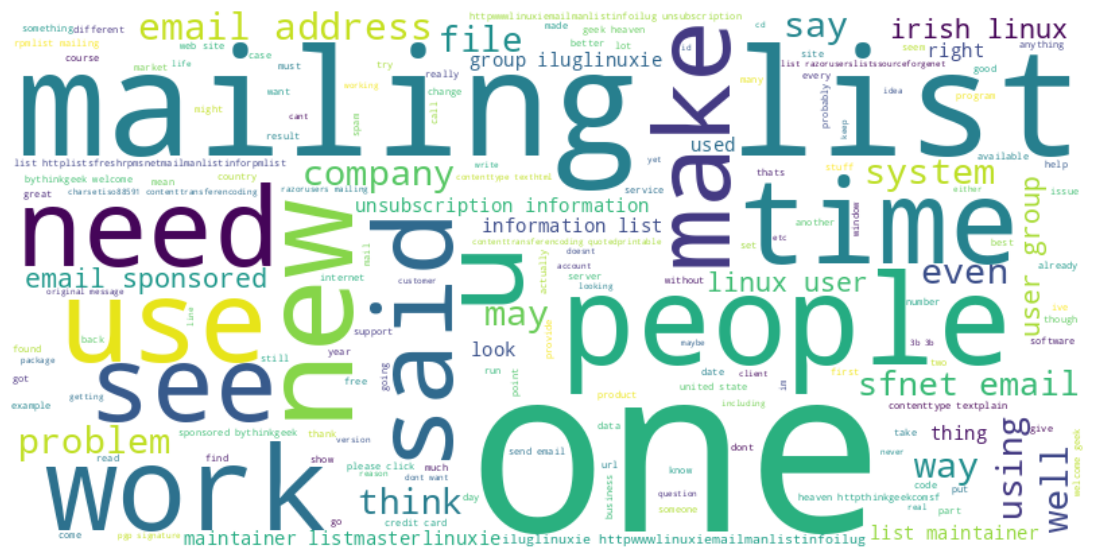

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [97]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words_list = [word for words_list in sentences for word in words_list]
all_words_string = ' '.join(all_words_list)

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_words_string)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

- Bar plots des mots les plus communs

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

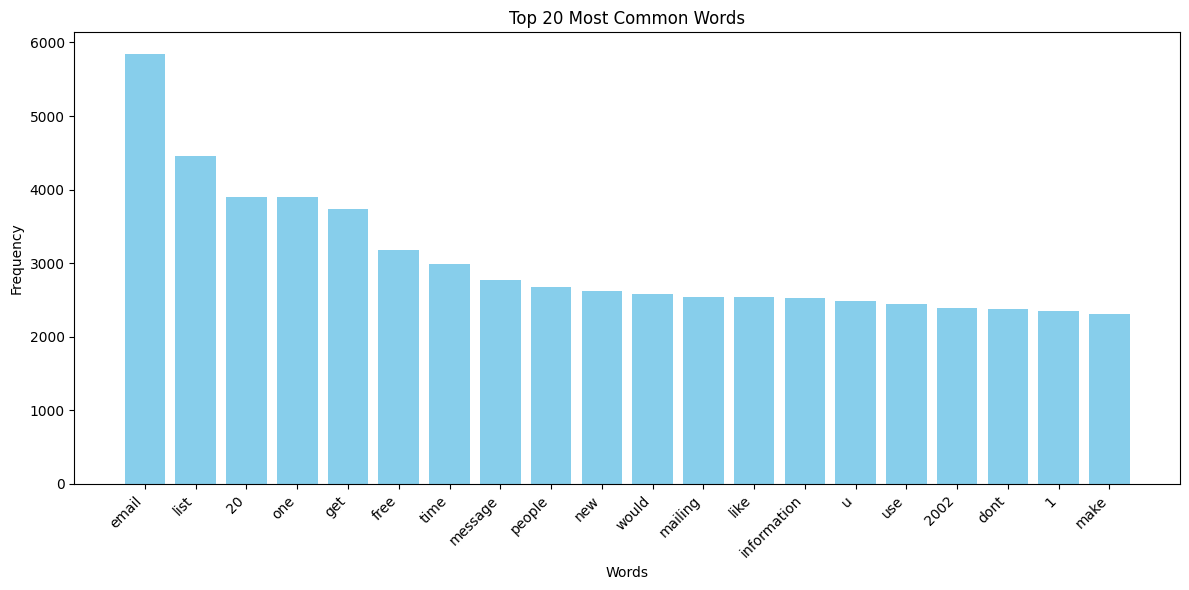

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [98]:
import matplotlib.pyplot as plt

most_common_words = word_counts.most_common(20)

words = [word for word, count in most_common_words]
counts = [count for word, count in most_common_words]

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='skyblue')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Common Words')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Histogrammes de la longueur des mails

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

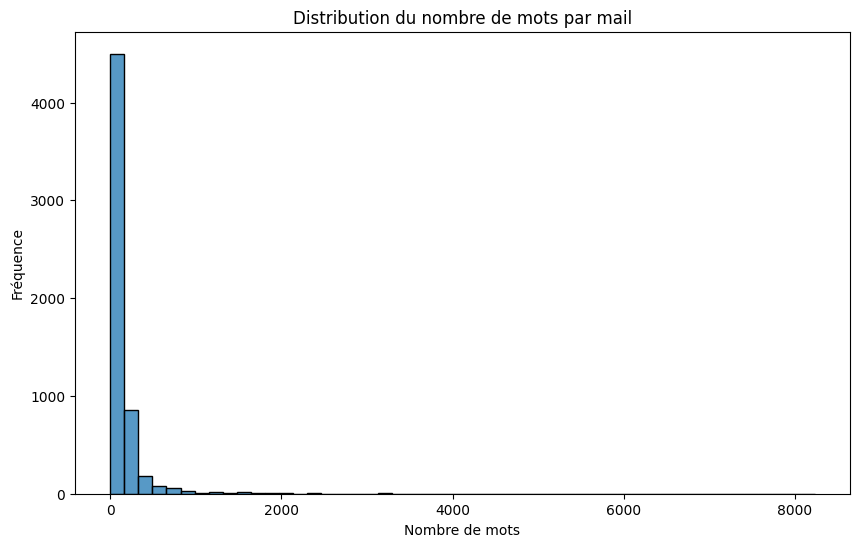

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

message_lengths = [len(tokens) for tokens in sentences]

plt.figure(figsize=(10, 6))
sns.histplot(message_lengths, bins=50)
plt.title("Distribution du nombre de mots par mail")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.show()

# Topic Modeling

- Topic Modeling sur les emails (LDA)

---



In [100]:
from gensim.corpora import Dictionary

# Create a Dictionary from the preprocessed texts
gen_dict = Dictionary(sentences)

# Create a Bag-of-Words corpus
corpus = [gen_dict.doc2bow(text) for text in sentences]

print("Number of unique tokens in dictionary:", len(gen_dict))
print("Sample corpus entry (first document):", corpus[0])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Number of unique tokens in dictionary: 81849
Sample corpus entry (first document): [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 4), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 2), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 2), (46, 1), (47, 1)]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

-distilBert
- LSTM

# Task
Train an LDA model using the `corpus` and `gen_dict` from the preprocessed email data, then visualize the topics using `pyLDAvis` to interpret the discovered topics and summarize their significance within the email dataset.

In [101]:
#Topic modeling
import gensim
import gensim.corpora as corpora
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Train LDA Model

### Subtask:
Train a Latent Dirichlet Allocation (LDA) model using the preprocessed email corpus and dictionary.


In [ ]:
# Entraîner un modèle LDA
from gensim.models.ldamodel import LdaModel

num_topics = 3  # par exemple

lda_model = LdaModel(
    corpus=corpus,
    id2word=gen_dict,
    num_topics=num_topics,
    random_state=42,
    update_every=1,
    chunksize=100,
    passes=10,
    alpha="auto",
    per_word_topics=True
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print("Topics:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic: {idx} \nWords: {topic}")
# Afficher les topics appris
# Chaque ligne donne un topic avec les mots les plus représentatifs et leurs poids

In [ ]:
# Obtenir les topics d’un email
# Pour voir de quels topics un mail est composé
doc_bow = corpus[0]               # premier email
doc_topics = lda_model.get_document_topics(doc_bow)
print(doc_topics)  # liste (id_topic, probabilité)

# Task
Visualize the topics extracted by the LDA model using `pyLDAvis` to interpret the topics and understand their inter-relationships, then summarize the key insights from the LDA topic modeling, including the discovered topics and their significance in the context of the email dataset.

## Visualize LDA Topics

### Subtask:
Use pyLDAvis to visualize the topics extracted by the LDA model. This visualization will help in interpreting the topics and understanding their inter-relationships.


**Reasoning**:
The subtask requires visualizing the LDA model, so I will import `pyLDAvis` and `pyLDAvis.gensim_models` and then prepare and display the interactive visualization.



In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models

# Prepare the interactive visualization
lda_display = pyLDAvis.gensim_models.prepare(lda_model, corpus, gen_dict)

# Display the prepared visualization
pyLDAvis.display(lda_display)

**Reasoning**:
I need to summarize the key insights from the LDA topic modeling. I will describe each topic identified by the LDA model and explain its significance in the context of the email dataset, drawing from the previously printed topics.

